In [40]:
# Import Libraries

import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)


In [43]:
INPUT_FILE = "data_cleaning_raw_dataset.csv"
OUTPUT_FILE = "cleaned_dataset.csv"
REPORT_FILE = "cleaning_summary_report.md"
os.makedirs("figures", exist_ok=True)

report = []
def log(msg):
    print(msg)
    report.append(msg)

In [47]:
# STEP 1 - Load the dataset & initial exploration

raw = pd.read_csv(INPUT_FILE)
df = raw.copy()

print("----- .head() -----")
print(df.head(), "\n")

print("----- .info() -----")
df.info()

print("\n----- .describe() (numeric) -----")
print(df.describe(), "\n")

print("----- .describe() (text columns) -----")
print(df.describe(exclude="number").T, "\n")

print("Shape:", df.shape)
print("Missing values per column:\n", df.isna().sum())

rows_raw, cols_raw = df.shape
missing_before = df.isna().sum()

----- .head() -----
  Customer_ID   Customer_Name  Age  Gender    City            Email Purchase_Amount  Purchase_Date Product_Category
0        C001   Rahul Sharma    25    Male    Pune  rahul@gmail.com          12,500     2026-01-15      Electronics
1        C002    Priya  Patil   28  Female  Mumbai  priya@gmail.com            8500     15/01/2026         Clothing
2        C003   Amit Deshmukh   31       M    Pune   amit@gmail.com           7,200     2026/02/10      electronics
3        C004     Sneha Joshi  NaN  Female  Nashik  sneha@gmail.com           15000  March 5, 2026          Grocery
4        C005  Rohan Kulkarni   42    male  Nagpur  rohan@gmail.com             NaN     2026-03-12         Clothing 

----- .info() -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Customer_ID       20 non-null     object
 1   Customer_Name    

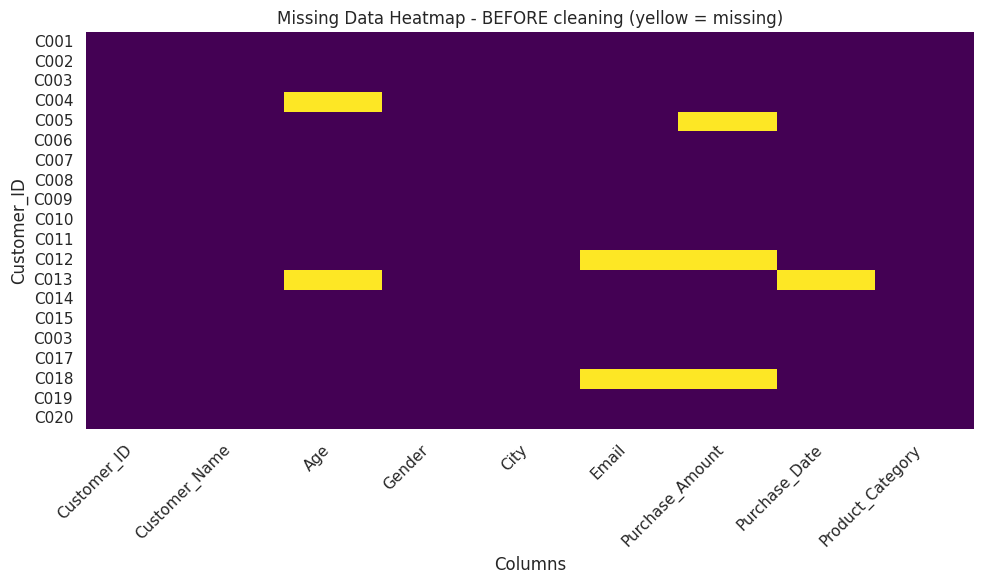

In [48]:
# STEP 2 - Visualise missing data (seaborn heatmap)
plt.figure(figsize=(10, 6))
sns.heatmap(df.isna(), cbar=False, cmap="viridis", yticklabels=df["Customer_ID"])
plt.title("Missing Data Heatmap - BEFORE cleaning (yellow = missing)")
plt.xlabel("Columns")
plt.ylabel("Customer_ID")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/01_missing_heatmap_before.png", dpi=150)
plt.show()

In [50]:
# STEP 3 - Missing-value strategy (per column)

# Text columns: trim, collapse repeated spaces, consistent case
df["Customer_Name"] = (df["Customer_Name"].str.strip()
                       .str.replace(r"\s+", " ", regex=True).str.title())
df["City"] = df["City"].str.strip().str.title()
df["Product_Category"] = df["Product_Category"].str.strip().str.title()
df["Gender"] = (df["Gender"].str.strip().str.lower()
                .map({"m": "Male", "male": "Male", "f": "Female", "female": "Female"}))

# Age: 'thirty' -> 30, everything else -> number
df["Age"] = df["Age"].replace({"thirty": "30"})
df["Age"] = pd.to_numeric(df["Age"], errors="coerce").astype("float64")

# Purchase_Amount: remove the rupee symbol and thousand-separator commas
df["Purchase_Amount"] = pd.to_numeric(
    df["Purchase_Amount"].astype("string").str.replace(r"[₹,\s]", "", regex=True),
    errors="coerce").astype("float64")

date_txt = df["Purchase_Date"].str.strip()
year_first = date_txt.str.match(r"^\d{4}", na=False)
parsed = pd.Series(pd.NaT, index=df.index, dtype="datetime64[ns]")
parsed[year_first] = pd.to_datetime(date_txt[year_first], format="mixed", errors="coerce")
parsed[~year_first] = pd.to_datetime(date_txt[~year_first], format="mixed",
                                     dayfirst=True, errors="coerce")
df["Purchase_Date"] = parsed

# Email: lowercase, then validate with a simple regex
df["Email"] = df["Email"].str.strip().str.lower()
valid_email = df["Email"].str.match(r"^[\w.\-]+@[\w\-]+\.[a-z]{2,}$", na=False)
log(f"Invalid/missing emails found: {(~valid_email).sum()}")

print("\nMissing values after standardising:\n", df.isna().sum(), "\n")

# Age (numeric, skewed by outlier)  -> MEDIAN (robust to the 120)
age_median = df["Age"].median()
n = df["Age"].isna().sum()
df["Age"] = df["Age"].fillna(age_median)
log(f"Age: {n} missing -> filled with median ({age_median:.0f})")

# Purchase_Amount -> MEDIAN of the same Product_Category (more realistic than
# the global median because spend differs by category)
n = df["Purchase_Amount"].isna().sum()
df["Purchase_Amount"] = df["Purchase_Amount"].fillna(
    df.groupby("Product_Category")["Purchase_Amount"].transform("median"))
df["Purchase_Amount"] = df["Purchase_Amount"].fillna(df["Purchase_Amount"].median())
log(f"Purchase_Amount: {n} missing -> filled with category-wise median")

# Email -> cannot be guessed. Mark invalid/missing as 'unknown' and keep a flag
n = (~valid_email).sum()
df["Email_Valid"] = valid_email
df.loc[~valid_email, "Email"] = "unknown"
log(f"Email: {n} missing/invalid -> set to 'unknown' + Email_Valid flag column")

# Purchase_Date -> rows are in chronological order of Customer_ID, so
# forward-fill uses the previous customer's date (closest reasonable estimate)
n = df["Purchase_Date"].isna().sum()
df["Purchase_Date"] = df["Purchase_Date"].ffill()
log(f"Purchase_Date: {n} missing -> forward-filled from previous record")

print("\nRemaining missing values:", int(df.isna().sum().sum()))

Invalid/missing emails found: 3

Missing values after standardising:
 Customer_ID         0
Customer_Name       0
Age                 2
Gender              0
City                0
Email               2
Purchase_Amount     3
Purchase_Date       1
Product_Category    0
dtype: int64 

Age: 2 missing -> filled with median (30)
Purchase_Amount: 3 missing -> filled with category-wise median
Email: 3 missing/invalid -> set to 'unknown' + Email_Valid flag column
Purchase_Date: 1 missing -> forward-filled from previous record

Remaining missing values: 0


In [51]:
#  Duplicate rows

print("Exact duplicates in RAW data     :", raw.duplicated().sum())
print("Exact duplicates after cleanup   :", df.duplicated().sum())
print("Duplicate Customer_IDs           :", df["Customer_ID"].duplicated().sum())

print("\nDuplicate rows:")
print(df[df.duplicated(keep=False)])

n_dups = int(df.duplicated().sum())
df = df.drop_duplicates(keep="first").reset_index(drop=True)
log(f"Duplicates: {n_dups} exact duplicate row(s) removed (Customer_ID C003)")
print("Shape now:", df.shape)


Exact duplicates in RAW data     : 0
Exact duplicates after cleanup   : 1
Duplicate Customer_IDs           : 1

Duplicate rows:
   Customer_ID  Customer_Name   Age Gender  City           Email  Purchase_Amount Purchase_Date Product_Category  Email_Valid
2         C003  Amit Deshmukh  31.0   Male  Pune  amit@gmail.com           7200.0    2026-02-10      Electronics         True
15        C003  Amit Deshmukh  31.0   Male  Pune  amit@gmail.com           7200.0    2026-02-10      Electronics         True
Duplicates: 1 exact duplicate row(s) removed (Customer_ID C003)
Shape now: (19, 10)


In [52]:
# STEP 5 - Rename columns to snake_case & correct data types
def to_snake(name):
    name = re.sub(r"[^\w\s]", "", name.strip())
    return re.sub(r"\s+", "_", name).lower()

df.columns = [to_snake(c) for c in df.columns]
print(list(df.columns))

df = df.astype({
    "customer_id": "string",
    "customer_name": "string",
    "age": "int64",
    "gender": "category",
    "city": "category",
    "email": "string",
    "purchase_amount": "float64",
    "product_category": "category",
    "email_valid": "bool",
})
# purchase_date is already datetime64 from Step 3
print("\n", df.dtypes)
log("Columns renamed to snake_case and dtypes corrected "
    "(age->int, purchase_amount->float, purchase_date->datetime, text->category)")

['customer_id', 'customer_name', 'age', 'gender', 'city', 'email', 'purchase_amount', 'purchase_date', 'product_category', 'email_valid']

 customer_id         string[python]
customer_name       string[python]
age                          int64
gender                    category
city                      category
email               string[python]
purchase_amount            float64
purchase_date       datetime64[ns]
product_category          category
email_valid                   bool
dtype: object
Columns renamed to snake_case and dtypes corrected (age->int, purchase_amount->float, purchase_date->datetime, text->category)


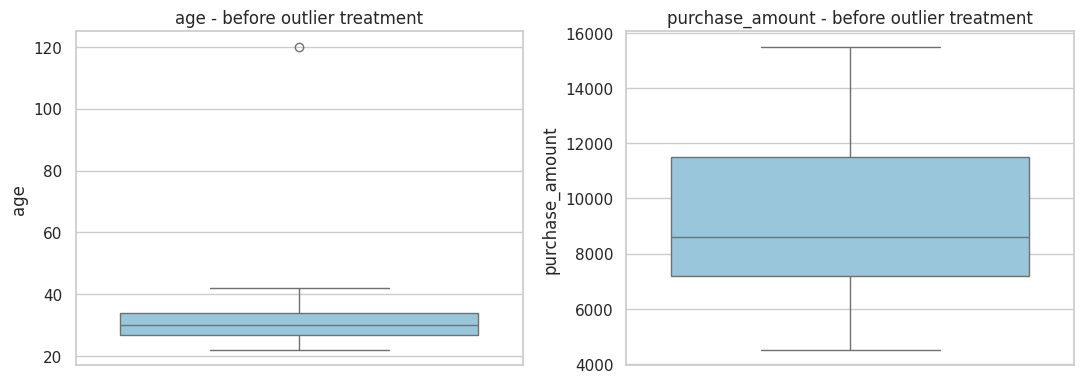


age: IQR bounds = [16.5, 44.5] -> 1 outlier(s)
   customer_id  age
15        C017  120

purchase_amount: IQR bounds = [750.0, 17950.0] -> 0 outlier(s)
Empty DataFrame
Columns: [customer_id, purchase_amount]
Index: []
Outliers: age -> 1 value(s) outside IQR bounds [16.5, 44.5] replaced with median; purchase_amount -> 0 outliers


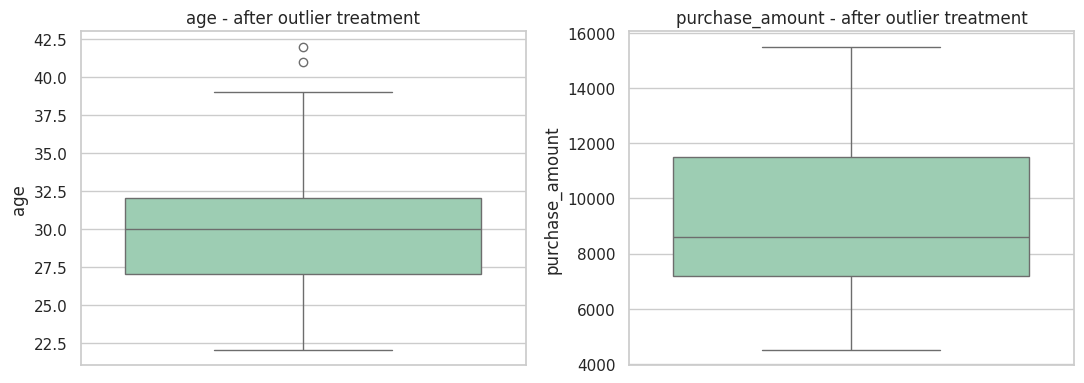

In [53]:
# STEP 6 - Outlier detection (box plots + IQR method)
def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

num_cols = ["age", "purchase_amount"]

# Box plots BEFORE treatment
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color="#8ecae6")
    ax.set_title(f"{col} - before outlier treatment")
plt.tight_layout()
plt.savefig("figures/02_boxplots_before.png", dpi=150)
plt.show()

outlier_info = {}
for col in num_cols:
    lo, hi = iqr_bounds(df[col])
    mask = (df[col] < lo) | (df[col] > hi)
    outlier_info[col] = (lo, hi, df.loc[mask, ["customer_id", col]])
    print(f"\n{col}: IQR bounds = [{lo:.1f}, {hi:.1f}] -> {mask.sum()} outlier(s)")
    print(df.loc[mask, ["customer_id", col]])

# Treatment: age 120 is impossible (data-entry error) -> replace with median.
# purchase_amount has no IQR outliers -> nothing to change.
lo, hi, _ = outlier_info["age"]
age_mask = (df["age"] < lo) | (df["age"] > hi)
n_age_out = int(age_mask.sum())
df.loc[age_mask, "age"] = int(df.loc[~age_mask, "age"].median())
log(f"Outliers: age -> {n_age_out} value(s) outside IQR bounds [{lo:.1f}, {hi:.1f}] "
    f"replaced with median; purchase_amount -> "
    f"{int(((df.purchase_amount < outlier_info['purchase_amount'][0]) | (df.purchase_amount > outlier_info['purchase_amount'][1])).sum())} outliers")

# Box plots AFTER treatment
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color="#95d5b2")
    ax.set_title(f"{col} - after outlier treatment")
plt.tight_layout()
plt.savefig("figures/03_boxplots_after.png", dpi=150)
plt.show()

In [54]:
# STEP 7 - Encode categorical columns
# Gender: only 2 values -> label (binary) encoding
df["gender_encoded"] = df["gender"].map({"Female": 0, "Male": 1}).astype("int64")

# City & Product_Category: no natural order -> one-hot encoding
# (original text columns are kept for readability; drop them before modelling)
dummies = pd.get_dummies(df[["city", "product_category"]],
                         prefix=["city", "category"], dtype=int)
dummies.columns = [c.lower() for c in dummies.columns]
df = pd.concat([df, dummies], axis=1)

print(df.head())
log(f"Encoding: gender -> label (Female=0, Male=1); "
    f"city & product_category -> one-hot ({dummies.shape[1]} new columns)")

  customer_id   customer_name  age  gender    city            email  purchase_amount purchase_date product_category  email_valid  gender_encoded  city_mumbai  city_nagpur  city_nashik  city_pune  \
0        C001    Rahul Sharma   25    Male    Pune  rahul@gmail.com          12500.0    2026-01-15      Electronics         True               1            0            0            0          1   
1        C002     Priya Patil   28  Female  Mumbai  priya@gmail.com           8500.0    2026-01-15         Clothing         True               0            1            0            0          0   
2        C003   Amit Deshmukh   31    Male    Pune   amit@gmail.com           7200.0    2026-02-10      Electronics         True               1            0            0            0          1   
3        C004     Sneha Joshi   30  Female  Nashik  sneha@gmail.com          15000.0    2026-03-05          Grocery         True               0            0            0            1          0   
4        C

Shape            : (19, 18)
Missing values   : 0
Duplicate rows   : 0
Dup customer IDs : 0

Dtypes:
 customer_id             string[python]
customer_name           string[python]
age                              int64
gender                        category
city                          category
email                   string[python]
purchase_amount                float64
purchase_date           datetime64[ns]
product_category              category
email_valid                       bool
gender_encoded                   int64
city_mumbai                      int64
city_nagpur                      int64
city_nashik                      int64
city_pune                        int64
category_clothing                int64
category_electronics             int64
category_grocery                 int64
dtype: object

Numeric summary:
              age  purchase_amount
count  19.000000        19.000000
mean   30.473684      9428.842105
std     5.480961      3083.532390
min    22.000000      4500.0

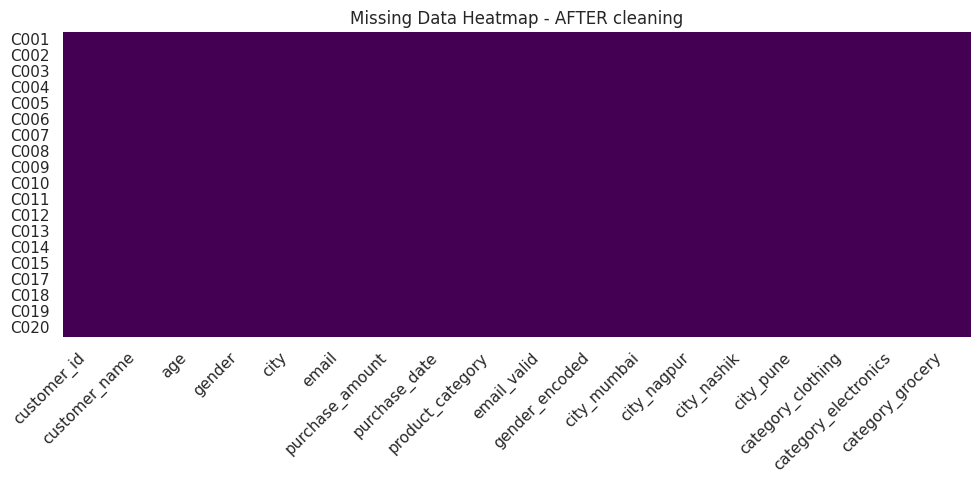

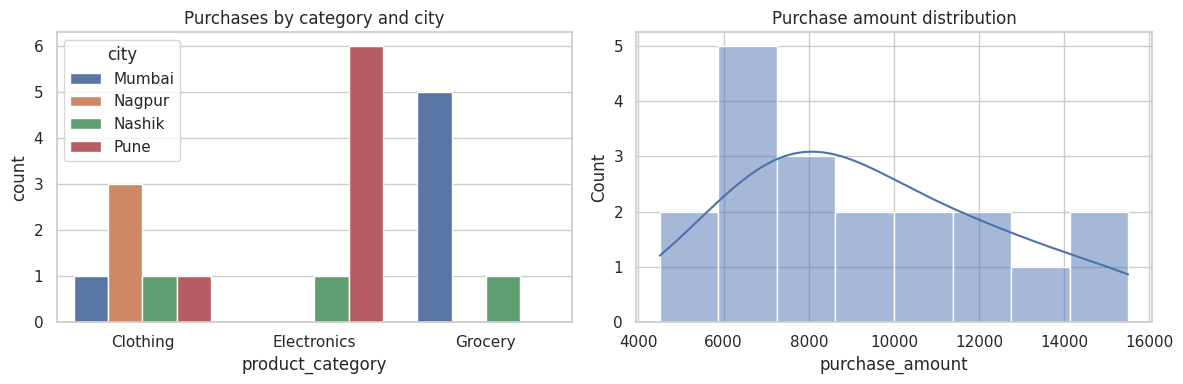

Validation: 0 missing values, 0 duplicates, all assertions passed


In [55]:
# STEP 8 - Validate the cleaned dataset
print("Shape            :", df.shape)
print("Missing values   :", int(df.isna().sum().sum()))
print("Duplicate rows   :", int(df.duplicated().sum()))
print("Dup customer IDs :", int(df["customer_id"].duplicated().sum()))
print("\nDtypes:\n", df.dtypes)
print("\nNumeric summary:\n", df[["age", "purchase_amount"]].describe())
print("\nDate range:", df["purchase_date"].min().date(), "->", df["purchase_date"].max().date())
print("\nValue counts:")
for c in ["gender", "city", "product_category"]:
    print(df[c].value_counts(), "\n")

# Assertions = automatic safety net
assert df.isna().sum().sum() == 0
assert not df.duplicated().any()
assert df["age"].between(0, 100).all()
assert df["purchase_amount"].gt(0).all()
assert set(df["gender"].astype(str)) <= {"Male", "Female"}

# Missing-data heatmap AFTER cleaning
plt.figure(figsize=(10, 5))
sns.heatmap(df.isna(), cbar=False, cmap="viridis", yticklabels=df["customer_id"])
plt.title("Missing Data Heatmap - AFTER cleaning")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/04_missing_heatmap_after.png", dpi=150)
plt.show()

# Quick look at the cleaned data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="product_category", hue="city", ax=axes[0])
axes[0].set_title("Purchases by category and city")
sns.histplot(df["purchase_amount"], bins=8, kde=True, ax=axes[1])
axes[1].set_title("Purchase amount distribution")
plt.tight_layout()
plt.savefig("figures/05_cleaned_overview.png", dpi=150)
plt.show()
log("Validation: 0 missing values, 0 duplicates, all assertions passed")

In [56]:
# STEP 9 - Export the cleaned dataset
df.to_csv(OUTPUT_FILE, index=False, date_format="%Y-%m-%d")
log(f"Exported cleaned dataset -> {OUTPUT_FILE} ({df.shape[0]} rows x {df.shape[1]} columns)")

Exported cleaned dataset -> cleaned_dataset.csv (19 rows x 18 columns)


In [57]:
# STEP 10 - Cleaning summary report
rows_final, cols_final = df.shape
lines = [
    "# Data Cleaning Summary Report",
    "",
    f"**Source file:** `{INPUT_FILE}`  |  **Output file:** `{OUTPUT_FILE}`",
    "",
    "## Overview",
    f"| Metric | Before | After |",
    f"|---|---|---|",
    f"| Rows | {rows_raw} | {rows_final} |",
    f"| Columns | {cols_raw} | {cols_final} (incl. encoded columns) |",
    f"| Missing values | {int(missing_before.sum())} (plus hidden bad values) | 0 |",
    f"| Duplicate rows | 0 visible (1 hidden) | 0 |",
    "",
    "## Missing values found (raw data)",
    "| Column | Missing |",
    "|---|---|",
] + [f"| {c} | {v} |" for c, v in missing_before.items() if v > 0] + [
    "",
    "## Actions taken",
] + [f"- {m}" for m in report] + [
    "",
    "## Other fixes",
    "- Names: trimmed extra spaces and applied Title Case.",
    "- Gender: M/F/male/female unified to Male/Female.",
    "- City: `pune` and `Mumbai ` (trailing space) unified.",
    "- Product category: `electronics` and `Clothing ` unified.",
    "- Age: text value `thirty` converted to 30.",
    "- Purchase_Amount: removed commas and the rupee symbol, converted to float.",
    "- Purchase_Date: 6 different formats parsed into one datetime format "
    "(day-first assumed for dd/mm/yyyy and dd-mm-yyyy).",
    "",
    "## Assumptions & limitations",
    "- Ambiguous dates such as `05/04/2026` were read as 5 April (day-first).",
    "- Imputed values (age median, category-median amount, forward-filled date) "
    "are estimates, not real observations.",
    "- Customer ID C016 is absent from the source data; it was not invented.",
    "- Rows with an unknown email are kept; use the `email_valid` flag to filter them.",
    "",
    "## Final column list",
    ", ".join(f"`{c}`" for c in df.columns),
]
with open(REPORT_FILE, "w", encoding="utf-8") as f:
    f.write("\n".join(lines))
print("\n".join(lines))

# Data Cleaning Summary Report

**Source file:** `data_cleaning_raw_dataset.csv`  |  **Output file:** `cleaned_dataset.csv`

## Overview
| Metric | Before | After |
|---|---|---|
| Rows | 20 | 19 |
| Columns | 9 | 18 (incl. encoded columns) |
| Missing values | 8 (plus hidden bad values) | 0 |
| Duplicate rows | 0 visible (1 hidden) | 0 |

## Missing values found (raw data)
| Column | Missing |
|---|---|
| Age | 2 |
| Email | 2 |
| Purchase_Amount | 3 |
| Purchase_Date | 1 |

## Actions taken
- Invalid/missing emails found: 3
- Age: 2 missing -> filled with median (30)
- Purchase_Amount: 3 missing -> filled with category-wise median
- Email: 3 missing/invalid -> set to 'unknown' + Email_Valid flag column
- Purchase_Date: 1 missing -> forward-filled from previous record
- Duplicates: 1 exact duplicate row(s) removed (Customer_ID C003)
- Columns renamed to snake_case and dtypes corrected (age->int, purchase_amount->float, purchase_date->datetime, text->category)
- Outliers: age -> 1 valu